In [37]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import itertools

In [38]:
def random_graph_min_degree(n, p):
    # 1. Create initial Erdős-Rényi graph
    G = nx.gnp_random_graph(n, p)
    
    # 2. Find nodes with degree 0
    isolated_nodes = [node for node, degree in G.degree() if degree == 0]
    
    # 3. Connect isolated nodes
    for node in isolated_nodes:
        # Connect to a random node, ensuring it's not self-loop
        target = random.choice([n for n in G.nodes() if n != node])
        G.add_edge(node, target)
        
    return G

In [39]:
def gnp_random_connected_graph(n, p):
    """
    Generates a random undirected graph, similarly to an Erdős-Rényi 
    graph, but enforcing that the resulting graph is conneted
    """
    edges = itertools.combinations(range(n), 2)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    if p <= 0:
        return G
    if p >= 1:
        return nx.complete_graph(n, create_using=G)
    for _, node_edges in itertools.groupby(edges, key=lambda x: x[0]):
        node_edges = list(node_edges)
        random_edge = random.choice(node_edges)
        G.add_edge(*random_edge)
        for e in node_edges:
            if random.random() < p:
                G.add_edge(*e)
    return G

In [46]:
N = 15

Many different graph types to consider. Random connected, star, lattice, linear, caveman
random connected and caveman might be best to consider here

scale-free to undirected scale-gree, make sure to remove loops (barabasi_albert_graph)

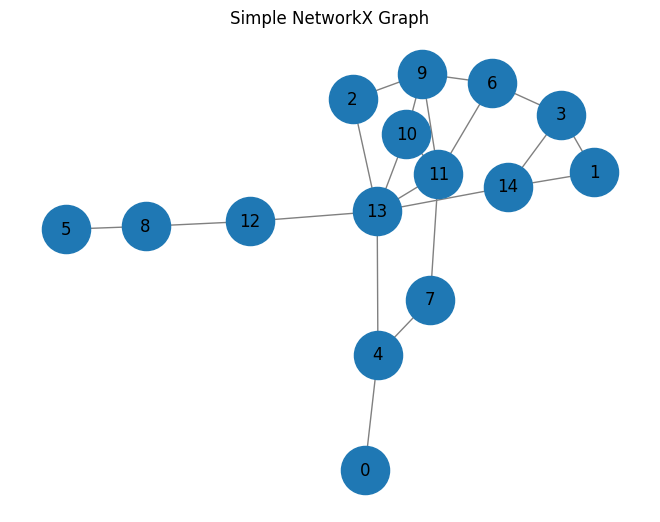

In [47]:


graph = gnp_random_connected_graph(N,0.1)


nx.draw(graph, with_labels=True, edge_color='gray', node_size=1200)
# , node_color='lightblue'
# 3. Display the plot
plt.title("Simple NetworkX Graph")
plt.show()

Steps:
generaate graph
generate W, stochastic adjacency matrix
place individuals onto graph (maybe move this step up once)

In [48]:
for node,attributes in graph.nodes(data=True):
    attributes['color'] = 'red'
    attributes['fitness'] = 1

W = np.zeros(N)